In [137]:
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [138]:
digits = load_digits()
df= pd.DataFrame(digits.data, columns=digits.feature_names)
df['target'] = digits.target
df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [139]:
digits.data[9].reshape(8, 8)

array([[ 0.,  0., 11., 12.,  0.,  0.,  0.,  0.],
       [ 0.,  2., 16., 16., 16., 13.,  0.,  0.],
       [ 0.,  3., 16., 12., 10., 14.,  0.,  0.],
       [ 0.,  1., 16.,  1., 12., 15.,  0.,  0.],
       [ 0.,  0., 13., 16.,  9., 15.,  2.,  0.],
       [ 0.,  0.,  0.,  3.,  0.,  9., 11.,  0.],
       [ 0.,  0.,  0.,  0.,  9., 15.,  4.,  0.],
       [ 0.,  0.,  9., 12., 13.,  3.,  0.,  0.]])

<Figure size 640x480 with 0 Axes>

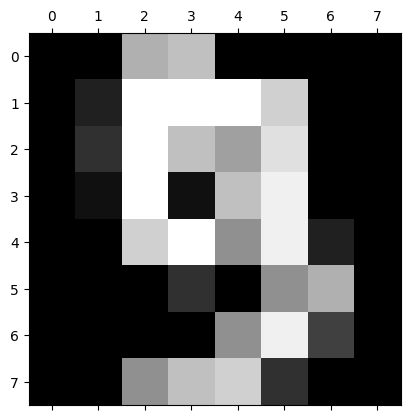

In [140]:
plt.gray()
plt.matshow(digits.images[9])
plt.show() 

In [141]:
df.describe()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496,4.490818
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122,2.865304
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000,2.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000,4.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000,7.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,9.000000


In [142]:
x= df.drop('target', axis=1)
y= df['target']

In [143]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled

array([[ 0.        , -0.33501649, -0.04308102, ..., -1.14664746,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  0.54856067,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  1.56568555,
         1.6951369 , -0.19600752],
       ...,
       [ 0.        , -0.33501649, -0.88456568, ..., -0.12952258,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -0.67419451, ...,  0.8876023 ,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649,  1.00877481, ...,  0.8876023 ,
        -0.26113572, -0.19600752]], shape=(1797, 64))

In [144]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1437, 64), (360, 64), (1437,), (360,))

In [145]:
model_logistic = LogisticRegression(max_iter=100)
model_logistic.fit(x_train, y_train)
model_logistic.score(x_test, y_test)

0.9722222222222222

In [146]:
pca = PCA(0.95)
x_pca= pca.fit_transform(x)
x_pca.shape

(1797, 29)

In [147]:
x_pca

array([[ -1.25946645, -21.27488348,   9.46305462, ...,   3.67072108,
          0.9436689 ,   1.13250195],
       [  7.9576113 ,  20.76869896,  -4.43950604, ...,   2.18261819,
          0.51022719,  -2.31354911],
       [  6.99192297,   9.95598641,  -2.95855808, ...,   4.22882114,
         -2.1576573 ,  -0.8379578 ],
       ...,
       [ 10.8012837 ,   6.96025223,  -5.59955453, ...,  -3.56866194,
         -1.82444444,  -3.53885886],
       [ -4.87210009, -12.42395362,  10.17086635, ...,   3.25330054,
         -0.95484174,   0.93895602],
       [ -0.34438963,  -6.36554919, -10.77370849, ...,  -3.01636722,
         -1.29752723,  -2.58810313]], shape=(1797, 29))

In [148]:
pca.explained_variance_ratio_

array([0.14890594, 0.13618771, 0.11794594, 0.08409979, 0.05782415,
       0.0491691 , 0.04315987, 0.03661373, 0.03353248, 0.03078806,
       0.02372341, 0.02272697, 0.01821863, 0.01773855, 0.01467101,
       0.01409716, 0.01318589, 0.01248138, 0.01017718, 0.00905617,
       0.00889538, 0.00797123, 0.00767493, 0.00722904, 0.00695889,
       0.00596081, 0.00575615, 0.00515158, 0.0048954 ])

In [149]:
pca.n_components_

np.int64(29)

In [150]:
x_train_pca, x_test_pca, y_train_pca, y_test_pca = train_test_split(x_pca, y, test_size=0.2, random_state=42)

In [151]:
model_pca= LogisticRegression(max_iter=1000)
model_pca.fit(x_train_pca, y_train_pca)
model_pca.score(x_test_pca, y_test_pca)

0.9611111111111111

In [152]:
pca2 = PCA(n_components=2)
x_pca2 = pca2.fit_transform(x)
x_pca2.shape

(1797, 2)

In [153]:
x_pca2

array([[ -1.25946645, -21.27488348],
       [  7.9576113 ,  20.76869896],
       [  6.99192297,   9.95598641],
       ...,
       [ 10.8012837 ,   6.96025223],
       [ -4.87210009, -12.42395362],
       [ -0.34438963,  -6.36554919]], shape=(1797, 2))

In [154]:
pca.explained_variance_ratio_

array([0.14890594, 0.13618771, 0.11794594, 0.08409979, 0.05782415,
       0.0491691 , 0.04315987, 0.03661373, 0.03353248, 0.03078806,
       0.02372341, 0.02272697, 0.01821863, 0.01773855, 0.01467101,
       0.01409716, 0.01318589, 0.01248138, 0.01017718, 0.00905617,
       0.00889538, 0.00797123, 0.00767493, 0.00722904, 0.00695889,
       0.00596081, 0.00575615, 0.00515158, 0.0048954 ])

In [155]:
x_train_pca2, x_test_pca2, y_train_pca2, y_test_pca2 = train_test_split(x_pca2, y, test_size=0.2, random_state=42)

In [156]:
model_pca2= LogisticRegression(max_iter=1000)
model_pca2.fit(x_train_pca2, y_train_pca2)
model_pca2.score(x_test_pca2, y_test_pca2)

0.6472222222222223

In [157]:
df2= pd.read_csv("heart.csv")
df2.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [158]:
df2.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [159]:
df2.shape

(918, 12)

In [160]:
df3 = df2[df2.Cholesterol<=(df2.Cholesterol.mean()+3*df2.Cholesterol.std())]
df3.shape

(915, 12)

In [161]:
df2[df2.MaxHR>(df2.MaxHR.mean()+3*df2.MaxHR.std())]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


In [162]:
df2[df2.FastingBS>(df2.FastingBS.mean()+3*df2.FastingBS.std())]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


In [163]:
df2[df2.Oldpeak>(df2.Oldpeak.mean()+3*df2.Oldpeak.std())]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
166,50,M,ASY,140,231,0,ST,140,Y,5.0,Flat,1
702,59,M,TA,178,270,0,LVH,145,N,4.2,Down,0
771,55,M,ASY,140,217,0,Normal,111,Y,5.6,Down,1
791,51,M,ASY,140,298,0,Normal,122,Y,4.2,Flat,1
850,62,F,ASY,160,164,0,LVH,145,N,6.2,Down,1
900,58,M,ASY,114,318,0,ST,140,N,4.4,Down,1


In [164]:
df4 = df3[df3.Oldpeak<=(df3.Oldpeak.mean()+3*df3.Oldpeak.std())]
df4.shape

(909, 12)

In [165]:
df2[df2.RestingBP>(df2.RestingBP.mean()+3*df2.RestingBP.std())]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
109,39,M,ATA,190,241,0,Normal,106,N,0.0,Up,0
241,54,M,ASY,200,198,0,Normal,142,Y,2.0,Flat,1
365,64,F,ASY,200,0,0,Normal,140,Y,1.0,Flat,1
399,61,M,NAP,200,0,1,ST,70,N,0.0,Flat,1
592,61,M,ASY,190,287,1,LVH,150,Y,2.0,Down,1
732,56,F,ASY,200,288,1,LVH,133,Y,4.0,Down,1
759,54,M,ATA,192,283,0,LVH,195,N,0.0,Up,1


In [166]:
df2.ChestPainType.unique()

array(['ATA', 'NAP', 'ASY', 'TA'], dtype=object)

In [167]:
df2.RestingECG.unique()

array(['Normal', 'ST', 'LVH'], dtype=object)

In [168]:
df2.ExerciseAngina.unique()

array(['N', 'Y'], dtype=object)

In [169]:
df2.ST_Slope.unique()

array(['Up', 'Flat', 'Down'], dtype=object)

In [170]:
df5 = df4.copy()
df5.ExerciseAngina.replace(
    {
        'N': 0,
        'Y': 1
    },
    inplace=True)

df5.ST_Slope.replace(
    {
        'Down': 1,
        'Flat': 2,
        'Up': 3
    },
    inplace=True
)

df5.RestingECG.replace(
    {
        'Normal': 1,
        'ST': 2,
        'LVH': 3
    },
    inplace=True)

df5.head()

C:\Users\Niloy\AppData\Local\Temp\ipykernel_46012\2954618829.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df5.ExerciseAngina.replace(
C:\Users\Niloy\AppData\Local\Temp\ipykernel_46012\2954618829.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df5.ExerciseAngina.replace(
C:\Users\Niloy\App

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,1,172,0,0.0,3,0
1,49,F,NAP,160,180,0,1,156,0,1.0,2,1
2,37,M,ATA,130,283,0,2,98,0,0.0,3,0
3,48,F,ASY,138,214,0,1,108,1,1.5,2,1
4,54,M,NAP,150,195,0,1,122,0,0.0,3,0


In [171]:
le= LabelEncoder()
df5.ChestPainType = le.fit_transform(df5.ChestPainType)
df5.Sex = le.fit_transform(df5.Sex)
df5.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,3,0
1,49,0,2,160,180,0,1,156,0,1.0,2,1
2,37,1,1,130,283,0,2,98,0,0.0,3,0
3,48,0,0,138,214,0,1,108,1,1.5,2,1
4,54,1,2,150,195,0,1,122,0,0.0,3,0


In [172]:
scaler_df5 = StandardScaler()
scaled_df5 = scaler_df5.fit_transform(df5.drop('HeartDisease', axis=1))
scaled_df5

array([[-1.43228867,  0.51576808,  0.22703297, ..., -0.82287409,
        -0.84660886,  1.04651643],
       [-0.47770182, -1.93885593,  1.27461148, ..., -0.82287409,
         0.13698962, -0.61366408],
       [-1.75048428,  0.51576808,  0.22703297, ..., -0.82287409,
        -0.84660886,  1.04651643],
       ...,
       [ 0.37081983,  0.51576808, -0.82054555, ...,  1.21525275,
         0.33370932, -0.61366408],
       [ 0.37081983, -1.93885593,  0.22703297, ..., -0.82287409,
        -0.84660886, -0.61366408],
       [-1.64441908,  0.51576808,  1.27461148, ..., -0.82287409,
        -0.84660886,  1.04651643]], shape=(909, 11))

In [173]:
yyy= df5['HeartDisease']
yyy.shape

(909,)

In [174]:
xxx_train_df5, xxx_test_df5, yyy_train_df5, yyy_test_df5 = train_test_split(scaled_df5, yyy, test_size=0.2, random_state=42)

In [175]:
xxx_train_df5.shape, xxx_test_df5.shape, yyy_train_df5.shape, yyy_test_df5.shape

((727, 11), (182, 11), (727,), (182,))

In [176]:
heat_model_logistic = LogisticRegression(max_iter=1000)
heat_model_logistic.fit(xxx_train_df5, yyy_train_df5)
heat_model_logistic.score(xxx_test_df5, yyy_test_df5)

0.8461538461538461

In [177]:
heart_model_svc = SVC()
heart_model_svc.fit(xxx_train_df5, yyy_train_df5)
heart_model_svc.score(xxx_test_df5, yyy_test_df5)

0.8791208791208791

In [178]:
heart_model_rf= RandomForestClassifier(n_estimators=100)
heart_model_rf.fit(xxx_train_df5, yyy_train_df5)
heart_model_rf.score(xxx_test_df5, yyy_test_df5)

0.8791208791208791

In [180]:
df5.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,3,0
1,49,0,2,160,180,0,1,156,0,1.0,2,1
2,37,1,1,130,283,0,2,98,0,0.0,3,0
3,48,0,0,138,214,0,1,108,1,1.5,2,1
4,54,1,2,150,195,0,1,122,0,0.0,3,0


In [181]:
heart_pca = PCA(0.95)
x_pca_heart= heart_pca.fit_transform(df5.drop('HeartDisease', axis=1))
x_pca_heart.shape

(909, 2)

In [182]:
x_pca_heart

array([[ 93.94004917,  29.12770235],
       [-15.50048614,  13.60738134],
       [ 83.33752997, -38.43742714],
       ...,
       [-67.50916885, -17.29870505],
       [ 40.83028485,  33.37969267],
       [-19.78764325,  37.13697973]], shape=(909, 2))

In [183]:
heart_x_pca_train, heart_x_pca_test, heart_y_pca_train, heart_y_pca_test = train_test_split(x_pca_heart, df5['HeartDisease'], test_size=0.2, random_state=42)
heart_x_pca_train.shape, heart_x_pca_test.shape, heart_y_pca_train.shape, heart_y_pca_test.shape

((727, 2), (182, 2), (727,), (182,))

In [184]:
heart_model_logistic_pca = LogisticRegression(max_iter=1000)
heart_model_logistic_pca.fit(heart_x_pca_train, heart_y_pca_train)
heart_model_logistic_pca.score(heart_x_pca_test, heart_y_pca_test)

0.6648351648351648

In [185]:
heart_model_svc_pca = SVC()
heart_model_svc_pca.fit(heart_x_pca_train, heart_y_pca_train)
heart_model_svc_pca.score(heart_x_pca_test, heart_y_pca_test)

0.7087912087912088

In [186]:
heart_model_rf_pca = RandomForestClassifier(n_estimators=100)
heart_model_rf_pca.fit(heart_x_pca_train, heart_y_pca_train)
heart_model_rf_pca.score(heart_x_pca_test, heart_y_pca_test)

0.6868131868131868